# AHEAD Synthetic Patients — Key Findings & Patterns

**Goal:** Surface what *stands out* in this cohort — the most abnormal biomarkers, clinical prevalences, demographic correlations, hidden patient segments, and unexpected observations.

---

| Section | Question answered |
|---|---|
| 1. Setup & data load | Shared infrastructure (same cleaning decisions as notebooks 1 & 2) |
| 2. Most commonly abnormal biomarkers | Which biomarkers are most often flagged Bad / Critical? |
| 3. Prevalence of specific clinical findings | How common are imaging findings, deficiencies, questionnaire flags? |
| 4. Demographic correlations with outcomes | How do age and gender relate to flag rates? |
| 5. Population clustering & segmentation | Are there distinct patient sub-groups? |
| 6. Unexpected / clinically noteworthy findings | Surprises, outliers, and paradoxes |

> **Cleaning decisions inherited from notebooks 1 & 2:**
> - `" copy"` files excluded (filename filter)
> - Questionnaire UUIDs normalised → `"patient_questionnaire"`
> - Patients appearing in multiple reports → latest export wins (dedup on `exported_at`)
> - `biomarker_id` used as primary key; `biomarker_name` is a display label only
> - `collected_on` missingness expected for image/questionnaire entries — filtered where needed
> - `value` missingness expected for non-numeric entries — always report n alongside statistics
> - All data is synthetic — findings are structural observations, not clinical prevalence estimates

## 1. Setup & Data Load

In [1]:
import json, os, glob
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid")
%matplotlib inline

# ── Paths & constants (identical to notebooks 1 & 2) ─────────────────────────
DATA_DIR = r"C:\Users\ABCLe\Downloads\synthetic_patient_datasets 2\ahead_synthetic_data"

# Questionnaire form-version UUIDs → normalised label (cleaning decision #3)
QUESTIONNAIRE_KEYS = {
    "0cfa9d7e-a9ac-491a-bffe-00c928b420b2",   # English questionnaire
    "8c0529a5-c943-4557-857f-ec2f93c309a1",   # German questionnaire
}

SEV_ORDER  = ["Normal", "Intermediate", "Bad", "Critical"]
SEV_COLORS = {"Normal": "#55A868", "Intermediate": "#FFC107",
              "Bad": "#DD8452",    "Critical": "#C44E52"}
SOURCE_COLORS = {"Blood": "#4C72B0", "ImageBiomarker": "#DD8452",
                 "Urine": "#55A868", "Unknown": "#888888"}
GENDER_COLORS = {"male": "#4C72B0", "female": "#DD8452",
                 "unknown": "#888888", "other": "#55A868"}

# ── Helpers ───────────────────────────────────────────────────────────────────
def normalise_fgk(key):
    return "patient_questionnaire" if key in QUESTIONNAIRE_KEYS else key

def ts_to_dt(ts):
    if isinstance(ts, dict) and "_seconds" in ts:
        return datetime.utcfromtimestamp(ts["_seconds"])
    return None

def flatten_dp(report_key, patient, dp):
    bio  = (dp.get("dataPoint") or {}).get("biomarkerData") or {}
    tags = (dp.get("dataPoint") or {}).get("tags") or {}
    asmt = (dp.get("dataPoint") or {}).get("assessment") or {}
    return {
        "report_key":     report_key,
        "patient_key":    patient.get("patientKey"),
        "patient_gender": patient.get("patientGender"),
        "patient_age":    patient.get("patientAge"),
        "file_group_key": normalise_fgk(dp.get("fileGroupKey")),
        "archived":       dp.get("archived"),
        "severity":       asmt.get("severity"),
        "organ":          tags.get("organ"),
        "source":         tags.get("source"),
        "info_type":      tags.get("infoType"),
        "biomarker_id":   bio.get("biomarkerId"),
        "biomarker_name": bio.get("biomarkerNameFromSource"),
        "value":          bio.get("value"),
        "collected_on":   ts_to_dt((dp.get("dataPoint") or {}).get("collectedOnDate")),
    }

# ── Load (skip " copy" files — cleaning decision #1) ─────────────────────────
json_files = [f for f in glob.glob(os.path.join(DATA_DIR, "*.json"))
              if " copy" not in os.path.basename(f)]

patient_rows, dp_rows = [], []
for path in json_files:
    rk = os.path.splitext(os.path.basename(path))[0]
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    for pt in data.get("patients", []):
        patient_rows.append({
            "report_key":       rk,
            "patient_key":      pt.get("patientKey"),
            "patient_gender":   pt.get("patientGender"),
            "patient_age":      pt.get("patientAge"),
            "patient_birthday": pt.get("patientBirthday"),
            "datapoint_count":  pt.get("datapointCount"),
            "exported_at":      data.get("exportedAt"),
        })
        for dp in pt.get("datapoints", []):
            dp_rows.append(flatten_dp(rk, pt, dp))

df_patients = pd.DataFrame(patient_rows)
df_dp       = pd.DataFrame(dp_rows)

# ── Type coercions ────────────────────────────────────────────────────────────
df_patients["patient_birthday"] = pd.to_datetime(df_patients["patient_birthday"], errors="coerce")
df_patients["exported_at"]      = pd.to_datetime(df_patients["exported_at"], errors="coerce")
df_dp["value"]                  = pd.to_numeric(df_dp["value"], errors="coerce")
df_dp["collected_on"]           = pd.to_datetime(df_dp["collected_on"], errors="coerce")
df_dp["patient_gender"]         = df_dp["patient_gender"].str.lower().str.strip().fillna("unknown")

# ── Deduplicate patients: latest report wins (cleaning decision #2) ───────────
unique_pts = (df_patients.sort_values("exported_at")
                         .drop_duplicates("patient_key", keep="last"))
N        = unique_pts["patient_key"].nunique()
age_map  = unique_pts.set_index("patient_key")["patient_age"]

# ── Flagged subset: Bad / Critical datapoints ─────────────────────────────────
flagged = df_dp[df_dp["severity"].isin(["Bad", "Critical"])].copy()

# Attach age from unique_pts (cleaning decision: use latest-export age)
df_dp["patient_age_val"]      = df_dp["patient_key"].map(age_map)
flagged["patient_age_val"]    = flagged["patient_key"].map(age_map)

print(f"✓  {len(json_files)} JSON files loaded")
print(f"✓  {N} unique patients  |  {len(df_dp):,} datapoints")
print(f"✓  {len(flagged):,} flagged datapoints (Bad / Critical)")

✓  62 JSON files loaded
✓  62 unique patients  |  8,421 datapoints
✓  791 flagged datapoints (Bad / Critical)


## 2. Most Commonly Abnormal Biomarkers

Which biomarkers are flagged **Bad or Critical** for the highest share of patients?  
We rank by patient prevalence (not datapoint count) to avoid inflation from repeat measurements.  
The secondary dot shows the *median flag rate* per measured patient — distinguishing **widely flagged** biomarkers from **severely flagged** ones.

C:\Users\ABCLe\AppData\Local\Temp\ipykernel_7096\2049564581.py:64: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from current font.
  plt.tight_layout()
c:\Users\ABCLe\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9670 (\N{BLACK DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


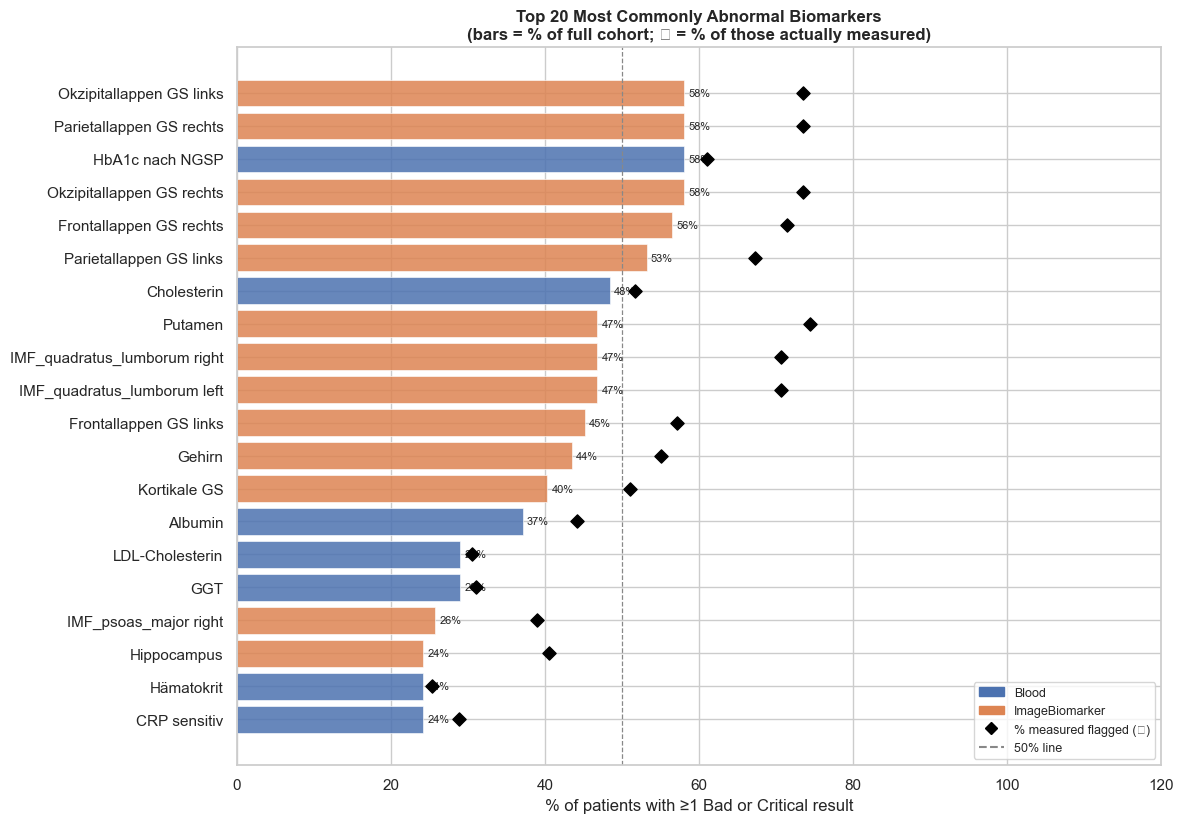

  TOP 20 MOST ABNORMAL BIOMARKERS — grouped by organ

  ▸ Cardiovascular01
    Biomarker                                  Source               % Cohort   % Measured
    ------------------------------------------ ------------------ ---------- ------------
    Cholesterin                                Blood                   48.4%        51.7%
    LDL-Cholesterin                            Blood                   29.0%        30.5%
    CRP sensitiv                               Blood                   24.2%        28.8%

  ▸ Digestive03
    Biomarker                                  Source               % Cohort   % Measured
    ------------------------------------------ ------------------ ---------- ------------
    Albumin                                    Blood                   37.1%        44.2%
    GGT                                        Blood                   29.0%        31.0%

  ▸ Hematologic10
    Biomarker                                  Source               % Cohort   

In [2]:
# ── 2a. Rank biomarkers by % of patients with ≥1 Bad/Critical result ─────────
# Use biomarker_id as primary key (cleaning decision #4: names are labels only)
organ_map  = (df_dp.dropna(subset=["biomarker_id", "organ"])
              .groupby("biomarker_id")["organ"].agg(lambda x: x.mode()[0]))
source_map = (df_dp.dropna(subset=["biomarker_id", "source"])
              .groupby("biomarker_id")["source"].agg(lambda x: x.mode()[0]))
name_map   = (df_dp.dropna(subset=["biomarker_id", "biomarker_name"])
              .groupby("biomarker_id")["biomarker_name"].agg(lambda x: x.mode()[0]))

# Patients measured per biomarker (denominator)
bio_measured = (df_dp.dropna(subset=["biomarker_id", "patient_key"])
                .groupby("biomarker_id")["patient_key"].nunique()
                .rename("n_measured"))

# Patients flagged per biomarker
bio_flagged = (flagged.dropna(subset=["biomarker_id", "patient_key"])
               .groupby("biomarker_id")["patient_key"].nunique()
               .rename("n_flagged"))

bio_stats = (pd.concat([bio_measured, bio_flagged], axis=1)
               .fillna(0)
               .assign(pct_flagged_of_measured=lambda d: (d["n_flagged"] / d["n_measured"] * 100).round(1),
                       pct_flagged_of_cohort  =lambda d: (d["n_flagged"] / N * 100).round(1))
               .join(name_map.rename("biomarker_name"))
               .join(organ_map.rename("organ"))
               .join(source_map.rename("source"))
               .reset_index())

top20 = (bio_stats.sort_values("pct_flagged_of_cohort", ascending=False)
                   .drop_duplicates("biomarker_name")   # keep highest-coverage name variant
                   .head(20)
                   .sort_values("pct_flagged_of_cohort", ascending=True)
                   .reset_index(drop=True))

# ── 2b. Horizontal bar chart with secondary dot ───────────────────────────────
bar_colors = [SOURCE_COLORS.get(s, "#888") for s in top20["source"]]

fig, ax = plt.subplots(figsize=(12, max(6, len(top20) * 0.42)))
bars = ax.barh(top20["biomarker_name"], top20["pct_flagged_of_cohort"],
               color=bar_colors, edgecolor="white", linewidth=0.5, alpha=0.85,
               label="% of cohort flagged")

# Secondary dot: % of measured patients (flag rate conditional on being measured)
ax.scatter(top20["pct_flagged_of_measured"], top20["biomarker_name"],
           color="black", zorder=5, s=45, marker="D",
           label="% of measured patients flagged (◆)")

ax.bar_label(bars, fmt="%.0f%%", padding=3, fontsize=8)
ax.axvline(50, color="#888", linestyle="--", linewidth=0.9, label="50% line")
ax.set_xlabel("% of patients with ≥1 Bad or Critical result")
ax.set_title("Top 20 Most Commonly Abnormal Biomarkers\n"
             "(bars = % of full cohort; ◆ = % of those actually measured)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 120)

legend_patches = [mpatches.Patch(color=c, label=s)
                  for s, c in SOURCE_COLORS.items() if s in top20["source"].values]
ax.legend(handles=legend_patches + [
    plt.Line2D([0], [0], marker="D", color="black", linestyle="", markersize=6,
               label="% measured flagged (◆)"),
    plt.Line2D([0], [0], color="#888", linestyle="--", label="50% line"),
], fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

# ── 2c. Summary table grouped by organ ───────────────────────────────────────
print(f"{'='*80}")
print(f"  TOP 20 MOST ABNORMAL BIOMARKERS — grouped by organ")
print(f"{'='*80}")
for organ, grp in (top20.sort_values(["organ", "pct_flagged_of_cohort"], ascending=[True, False])
                         .groupby("organ", sort=False)):
    print(f"\n  ▸ {organ}")
    print(f"    {'Biomarker':<42} {'Source':<18} {'% Cohort':>10} {'% Measured':>12}")
    print(f"    {'-'*42} {'-'*18} {'-'*10} {'-'*12}")
    for _, r in grp.iterrows():
        print(f"    {r['biomarker_name']:<42} {r['source']:<18} "
              f"{r['pct_flagged_of_cohort']:>9.1f}% {r['pct_flagged_of_measured']:>11.1f}%")
print(f"\n{'='*80}")

## 3. Prevalence of Specific Clinical Findings

What fraction of patients have findings in each clinical category?  
We focus on three categories: **imaging biomarkers**, **nutritional / metabolic deficiencies** (keyword-matched), and **questionnaire-derived flags**.  
Findings in > 50 % of patients are highlighted as high-prevalence.

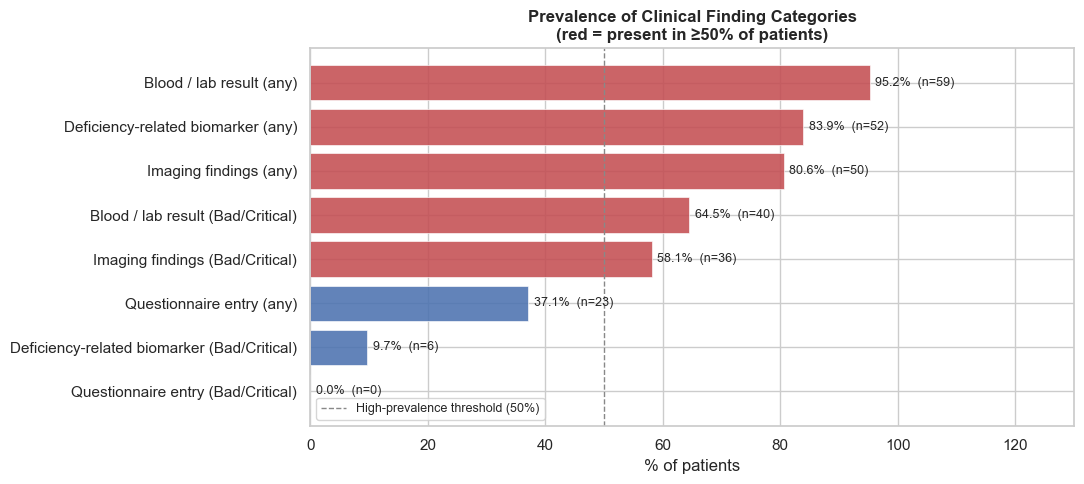

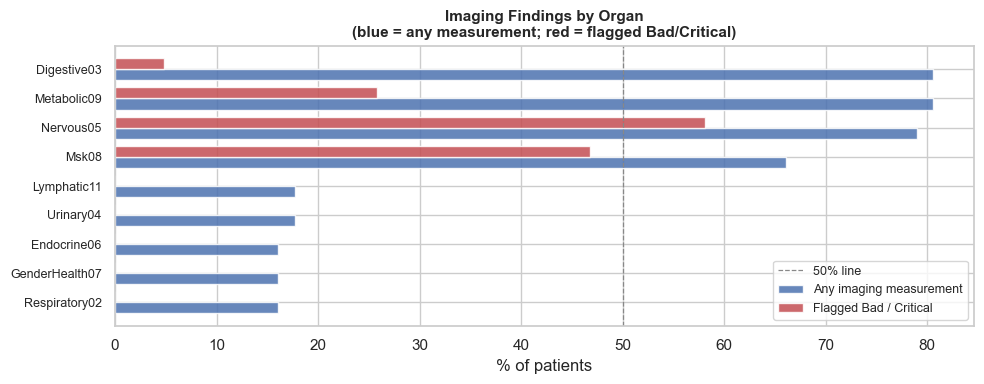

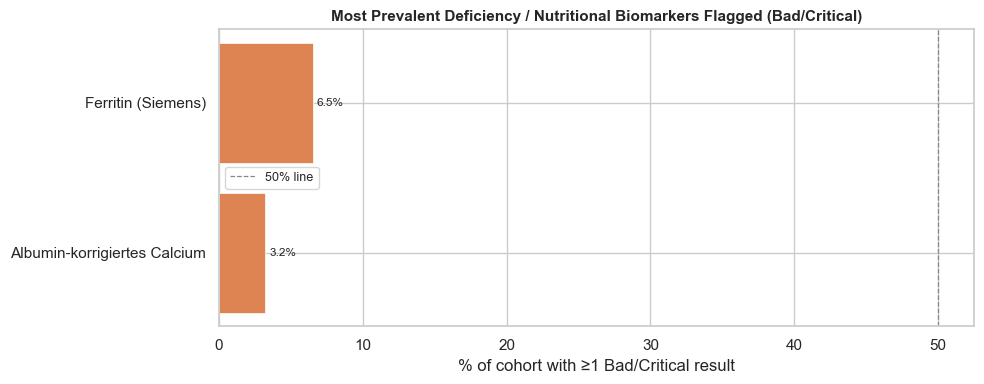

In [3]:
# ── 3a. Category definitions ──────────────────────────────────────────────────
DEFICIENCY_KEYWORDS = [
    "vitamin", "deficiency", "ferritin", "iron", "folate", "b12",
    "magnesium", "zinc", "calcium", "phosphate", "iodine", "selenium",
]

def is_deficiency(name):
    if pd.isna(name):
        return False
    n = name.lower()
    return any(kw in n for kw in DEFICIENCY_KEYWORDS)

# ── 3b. Per-category prevalence ───────────────────────────────────────────────
prev_rows = []

# (A) Imaging findings: any datapoint with source == "ImageBiomarker"
img_pts = df_dp[df_dp["source"] == "ImageBiomarker"]["patient_key"].nunique()
img_flagged_pts = flagged[flagged["source"] == "ImageBiomarker"]["patient_key"].nunique()

prev_rows.append({"category": "Imaging findings (any)",
                  "n_patients": img_pts,
                  "pct": round(img_pts / N * 100, 1)})
prev_rows.append({"category": "Imaging findings (Bad/Critical)",
                  "n_patients": img_flagged_pts,
                  "pct": round(img_flagged_pts / N * 100, 1)})

# (B) Nutritional / metabolic deficiency-related biomarkers
def_mask = df_dp["biomarker_name"].apply(is_deficiency)
def_pts  = df_dp[def_mask]["patient_key"].nunique()
def_flagged_pts = flagged[flagged["biomarker_name"].apply(is_deficiency)]["patient_key"].nunique()

prev_rows.append({"category": "Deficiency-related biomarker (any)",
                  "n_patients": def_pts,
                  "pct": round(def_pts / N * 100, 1)})
prev_rows.append({"category": "Deficiency-related biomarker (Bad/Critical)",
                  "n_patients": def_flagged_pts,
                  "pct": round(def_flagged_pts / N * 100, 1)})

# (C) Questionnaire-derived flags
q_mask = df_dp["file_group_key"] == "patient_questionnaire"
q_pts  = df_dp[q_mask]["patient_key"].nunique()
q_flagged_pts = flagged[flagged["file_group_key"] == "patient_questionnaire"]["patient_key"].nunique()

prev_rows.append({"category": "Questionnaire entry (any)",
                  "n_patients": q_pts,
                  "pct": round(q_pts / N * 100, 1)})
prev_rows.append({"category": "Questionnaire entry (Bad/Critical)",
                  "n_patients": q_flagged_pts,
                  "pct": round(q_flagged_pts / N * 100, 1)})

# (D) Blood / lab findings
blood_pts = df_dp[df_dp["source"] == "Blood"]["patient_key"].nunique()
blood_flagged_pts = flagged[flagged["source"] == "Blood"]["patient_key"].nunique()

prev_rows.append({"category": "Blood / lab result (any)",
                  "n_patients": blood_pts,
                  "pct": round(blood_pts / N * 100, 1)})
prev_rows.append({"category": "Blood / lab result (Bad/Critical)",
                  "n_patients": blood_flagged_pts,
                  "pct": round(blood_flagged_pts / N * 100, 1)})

df_prev = (pd.DataFrame(prev_rows)
             .sort_values("pct", ascending=True)
             .reset_index(drop=True))

# ── 3c. Plot ───────────────────────────────────────────────────────────────────
HIGH_PREV = 50
colors_prev = ["#C44E52" if p >= HIGH_PREV else "#4C72B0" for p in df_prev["pct"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(df_prev["category"], df_prev["pct"],
               color=colors_prev, edgecolor="white", linewidth=0.5, alpha=0.88)
ax.bar_label(bars, labels=[f"{p}%  (n={n})" for p, n in
                            zip(df_prev["pct"], df_prev["n_patients"])],
             padding=4, fontsize=9)
ax.axvline(HIGH_PREV, color="#888", linestyle="--", linewidth=1,
           label=f"High-prevalence threshold ({HIGH_PREV}%)")
ax.set_xlabel("% of patients")
ax.set_title("Prevalence of Clinical Finding Categories\n"
             "(red = present in ≥50% of patients)", fontsize=12, fontweight="bold")
ax.set_xlim(0, 130)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── 3d. Imaging findings by organ — prevalence breakdown ─────────────────────
img_organ = (df_dp[df_dp["source"] == "ImageBiomarker"]
             .dropna(subset=["organ"])
             .groupby("organ")["patient_key"].nunique()
             .div(N).mul(100).round(1)
             .sort_values(ascending=False)
             .rename("pct_with_imaging")
             .reset_index())

img_organ_flagged = (flagged[flagged["source"] == "ImageBiomarker"]
                     .dropna(subset=["organ"])
                     .groupby("organ")["patient_key"].nunique()
                     .div(N).mul(100).round(1)
                     .rename("pct_flagged")
                     .reset_index())

img_combined = img_organ.merge(img_organ_flagged, on="organ", how="left").fillna(0)

fig, ax = plt.subplots(figsize=(10, max(4, len(img_combined) * 0.4)))
y = np.arange(len(img_combined))
h = 0.38
ax.barh(y + h/2, img_combined["pct_with_imaging"], height=h, color="#4C72B0",
        alpha=0.85, edgecolor="white", label="Any imaging measurement")
ax.barh(y - h/2, img_combined["pct_flagged"], height=h, color="#C44E52",
        alpha=0.85, edgecolor="white", label="Flagged Bad / Critical")
ax.set_yticks(y)
ax.set_yticklabels(img_combined["organ"], fontsize=9)
ax.set_xlabel("% of patients")
ax.set_title("Imaging Findings by Organ\n(blue = any measurement; red = flagged Bad/Critical)",
             fontsize=11, fontweight="bold")
ax.axvline(HIGH_PREV, color="#888", linestyle="--", linewidth=0.9, label="50% line")
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── 3e. Top deficiency biomarkers flagged ─────────────────────────────────────
top_def = (flagged[flagged["biomarker_name"].apply(is_deficiency)]
           .dropna(subset=["biomarker_name"])
           .groupby("biomarker_name")["patient_key"].nunique()
           .div(N).mul(100).round(1)
           .sort_values(ascending=False)
           .head(15)
           .rename("pct_flagged")
           .reset_index())

if not top_def.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(top_def) * 0.38)))
    colors_def = ["#C44E52" if p >= HIGH_PREV else "#DD8452" for p in top_def["pct_flagged"]]
    bars = ax.barh(top_def["biomarker_name"], top_def["pct_flagged"],
                   color=colors_def, edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8.5)
    ax.axvline(HIGH_PREV, color="#888", linestyle="--", linewidth=0.9, label="50% line")
    ax.set_xlabel("% of cohort with ≥1 Bad/Critical result")
    ax.set_title("Most Prevalent Deficiency / Nutritional Biomarkers Flagged (Bad/Critical)",
                 fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No deficiency-related biomarkers found with Bad/Critical flags.")

## 4. Demographic Correlations with Health Outcomes

Does age or gender predict how many abnormal results a patient has?

1. **Scatter:** per-patient age vs. % of datapoints flagged, coloured by gender + regression line  
2. **Heatmap:** mean flag rate per organ × age band, faceted by gender  
3. **Correlation table:** Spearman ρ between age and Bad/Critical count, per gender

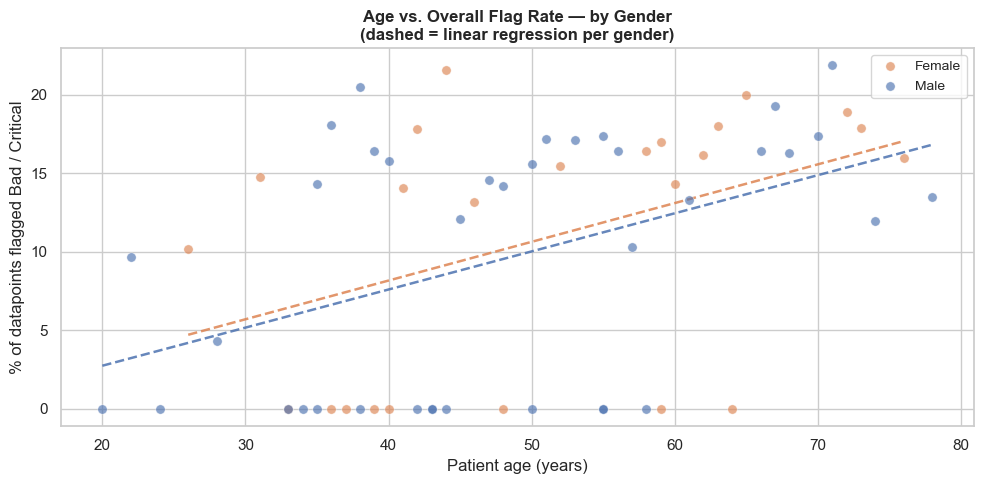

c:\Users\ABCLe\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)
c:\Users\ABCLe\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


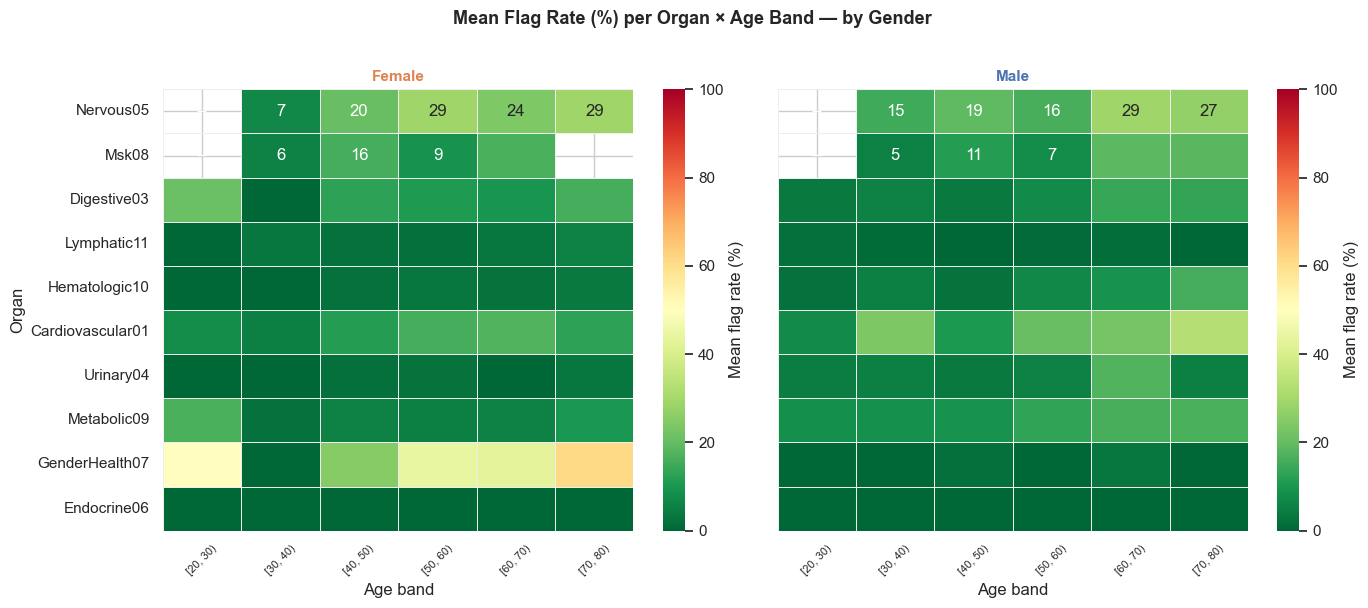


  Spearman ρ: patient age vs. # Bad/Critical datapoints
  Gender           n         ρ     p-value  Significance
  ------------ -----  --------  ----------  --------------
  Female          24     0.287      0.1743  ns
  Male            38     0.428      0.0073  **
Sig. codes: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant


In [4]:
# ── 4a. Build per-patient summary frame ──────────────────────────────────────
pt_summary = (df_dp.groupby("patient_key")
              .agg(n_total=("severity", "count"),
                   n_flagged=("severity", lambda s: s.isin(["Bad","Critical"]).sum()),
                   patient_gender=("patient_gender", "first"))
              .reset_index())

pt_summary["patient_age"]   = pt_summary["patient_key"].map(age_map)
pt_summary["pct_flagged"]   = (pt_summary["n_flagged"] / pt_summary["n_total"] * 100).round(1)
pt_summary                  = pt_summary.dropna(subset=["patient_age"])

# ── 4b. Scatter: age vs. % flagged by gender + regression lines ───────────────
fig, ax = plt.subplots(figsize=(10, 5))
genders_s = sorted(pt_summary["patient_gender"].unique())

for gender in genders_s:
    sub = pt_summary[pt_summary["patient_gender"] == gender]
    col = GENDER_COLORS.get(gender, "#888")
    ax.scatter(sub["patient_age"], sub["pct_flagged"],
               color=col, alpha=0.65, s=45, edgecolors="white", linewidths=0.4,
               label=gender.capitalize(), zorder=3)
    if len(sub) >= 3:
        m, b = np.polyfit(sub["patient_age"], sub["pct_flagged"], 1)
        x_rng = np.linspace(sub["patient_age"].min(), sub["patient_age"].max(), 100)
        ax.plot(x_rng, m * x_rng + b, color=col, linewidth=1.8,
                linestyle="--", alpha=0.85)

ax.set_xlabel("Patient age (years)")
ax.set_ylabel("% of datapoints flagged Bad / Critical")
ax.set_title("Age vs. Overall Flag Rate — by Gender\n(dashed = linear regression per gender)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── 4c. Heatmap: mean flag rate per organ × age band, per gender ──────────────
# 10-year age bins
pt_summary["age_band"] = pd.cut(
    pt_summary["patient_age"],
    bins=range(int(pt_summary["patient_age"].min() // 10 * 10),
               int(pt_summary["patient_age"].max() // 10 * 10) + 20, 10),
    right=False
).astype(str)

# Per-patient, per-organ flag rate
pt_organ = (df_dp.dropna(subset=["organ"])
            .groupby(["patient_key", "organ"])
            .agg(n_total=("severity", "count"),
                 n_flagged=("severity", lambda s: s.isin(["Bad","Critical"]).sum()))
            .reset_index())
pt_organ["flag_rate"] = pt_organ["n_flagged"] / pt_organ["n_total"] * 100
pt_organ = pt_organ.merge(
    pt_summary[["patient_key", "patient_age", "patient_gender", "age_band"]],
    on="patient_key", how="left"
).dropna(subset=["patient_age"])

top_organs_hmap = df_dp["organ"].value_counts().head(10).index.tolist()
genders_hmap = [g for g in ["female", "male", "other", "unknown"]
                if g in pt_organ["patient_gender"].unique()]

fig, axes = plt.subplots(1, len(genders_hmap),
                         figsize=(7 * len(genders_hmap), 6),
                         sharey=True)
if len(genders_hmap) == 1:
    axes = [axes]

for ax, gender in zip(axes, genders_hmap):
    sub = pt_organ[(pt_organ["patient_gender"] == gender) &
                   (pt_organ["organ"].isin(top_organs_hmap))]
    hmap_data = (sub.groupby(["organ", "age_band"])["flag_rate"]
                   .mean()
                   .unstack(fill_value=np.nan)
                   .reindex(top_organs_hmap))

    # Sort age bands chronologically
    sorted_cols = sorted(hmap_data.columns,
                         key=lambda s: int(s.split(",")[0].replace("[", "").strip())
                         if s != "nan" else 9999)
    hmap_data = hmap_data[[c for c in sorted_cols if c in hmap_data.columns]]

    sns.heatmap(hmap_data, ax=ax, cmap="RdYlGn_r", vmin=0, vmax=100,
                annot=True, fmt=".0f", linewidths=0.4, linecolor="#eee",
                cbar_kws={"label": "Mean flag rate (%)"})
    ax.set_title(f"{gender.capitalize()}", fontsize=11, fontweight="bold",
                 color=GENDER_COLORS.get(gender, "#333"))
    ax.set_xlabel("Age band")
    ax.set_ylabel("Organ" if gender == genders_hmap[0] else "")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

fig.suptitle("Mean Flag Rate (%) per Organ × Age Band — by Gender",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── 4d. Spearman correlation: age ↔ n_flagged per gender ─────────────────────
print(f"\n{'='*60}")
print("  Spearman ρ: patient age vs. # Bad/Critical datapoints")
print(f"{'='*60}")
print(f"  {'Gender':<12} {'n':>5}  {'ρ':>8}  {'p-value':>10}  {'Significance'}")
print(f"  {'-'*12} {'-'*5}  {'-'*8}  {'-'*10}  {'-'*14}")
for gender in genders_s:
    sub = pt_summary[pt_summary["patient_gender"] == gender].dropna(subset=["patient_age"])
    if len(sub) < 3:
        continue
    r, p = stats.spearmanr(sub["patient_age"], sub["n_flagged"])
    sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {gender.capitalize():<12} {len(sub):>5}  {r:>8.3f}  {p:>10.4f}  {sig}")
print(f"{'='*60}\nSig. codes: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")

## 5. Population Clustering & Segmentation

Are there distinct sub-groups of patients with different health profiles?

**Method:**
1. Build a per-patient feature matrix: age (normalised) + gender (one-hot) + per-organ flag rate
2. Impute missing values with column medians
3. Elbow plot + silhouette scores to choose *k*
4. KMeans clustering → 2D PCA visualisation
5. Cluster profile heatmap + plain-language summary card per cluster

Feature matrix: 62 patients × 15 features


c:\Users\ABCLe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ABCLe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ABCLe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ABCLe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

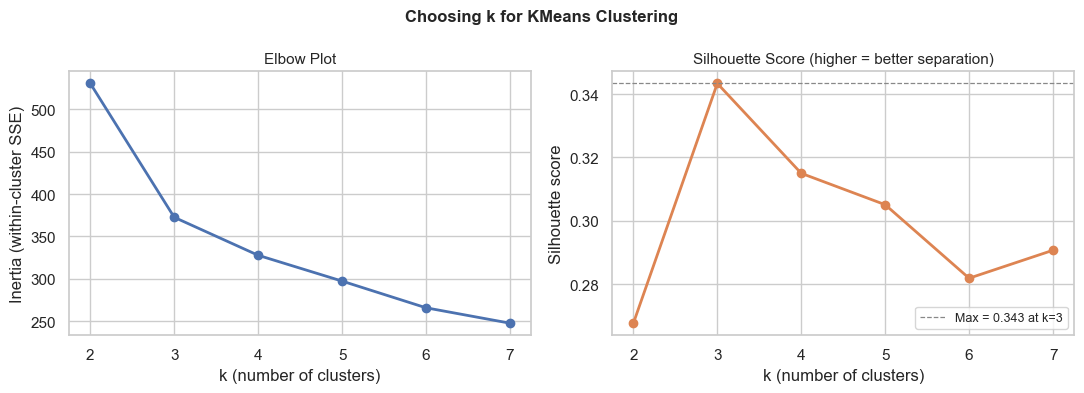


→ Selected k = 3  (highest silhouette score = 0.343)


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ── 5a. Build per-patient feature matrix ──────────────────────────────────────
# Per-organ flag rate (Bad/Critical datapoints / total datapoints per organ)
organs_feat = df_dp["organ"].value_counts().head(15).index.tolist()

pt_organ_rate = (df_dp[df_dp["organ"].isin(organs_feat)]
                 .groupby(["patient_key", "organ"])
                 .apply(lambda g: g["severity"].isin(["Bad","Critical"]).sum() / len(g) * 100)
                 .unstack(fill_value=np.nan)
                 .rename(columns=lambda o: f"organ_{o}_flag_rate"))

# Age (from unique_pts)
age_feat = unique_pts.set_index("patient_key")[["patient_age"]].rename(
    columns={"patient_age": "age"})

# Gender one-hot
gender_feat = (unique_pts.assign(
    gender_lower=lambda d: d["patient_gender"].str.lower().str.strip().fillna("unknown"))
    .set_index("patient_key")[["gender_lower"]]
    .pipe(lambda d: pd.get_dummies(d, columns=["gender_lower"], prefix="gender")))

feat_matrix = (pt_organ_rate
               .join(age_feat, how="left")
               .join(gender_feat, how="left"))

# Impute missing with column median (organs not measured for a patient)
feat_matrix = feat_matrix.apply(lambda col: col.fillna(col.median()))

# Standardise
scaler = StandardScaler()
X = scaler.fit_transform(feat_matrix)
print(f"Feature matrix: {X.shape[0]} patients × {X.shape[1]} features")

# ── 5b. Elbow plot + silhouette scores ────────────────────────────────────────
K_RANGE = range(2, 8)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(K_RANGE), inertias, "o-", color="#4C72B0", linewidth=2)
ax1.set_xlabel("k (number of clusters)")
ax1.set_ylabel("Inertia (within-cluster SSE)")
ax1.set_title("Elbow Plot", fontsize=11)

ax2.plot(list(K_RANGE), silhouettes, "o-", color="#DD8452", linewidth=2)
ax2.set_xlabel("k (number of clusters)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette Score (higher = better separation)", fontsize=11)
ax2.axhline(max(silhouettes), color="#888", linestyle="--", linewidth=0.9,
            label=f"Max = {max(silhouettes):.3f} at k={list(K_RANGE)[silhouettes.index(max(silhouettes))]}")
ax2.legend(fontsize=9)

plt.suptitle("Choosing k for KMeans Clustering", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Choose k automatically as the one with highest silhouette
BEST_K = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f"\n→ Selected k = {BEST_K}  (highest silhouette score = {max(silhouettes):.3f})")

c:\Users\ABCLe\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


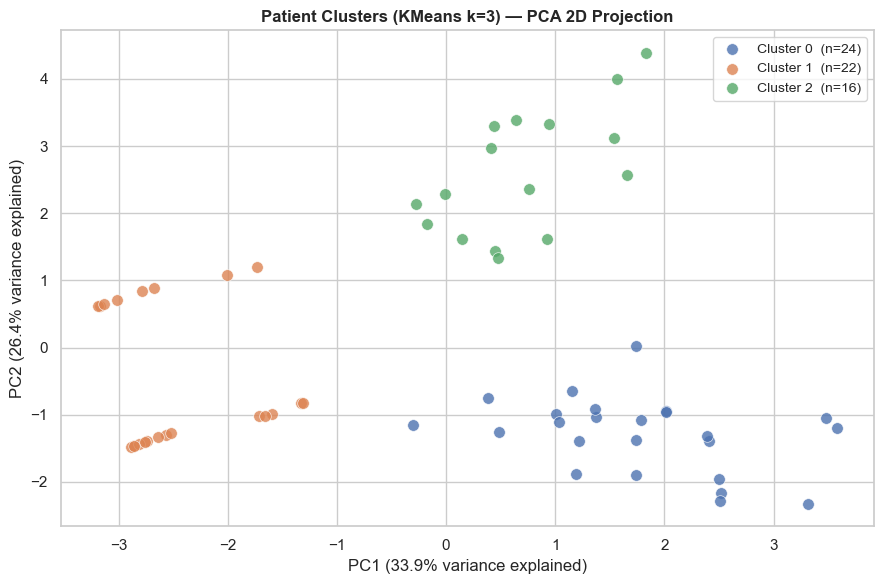

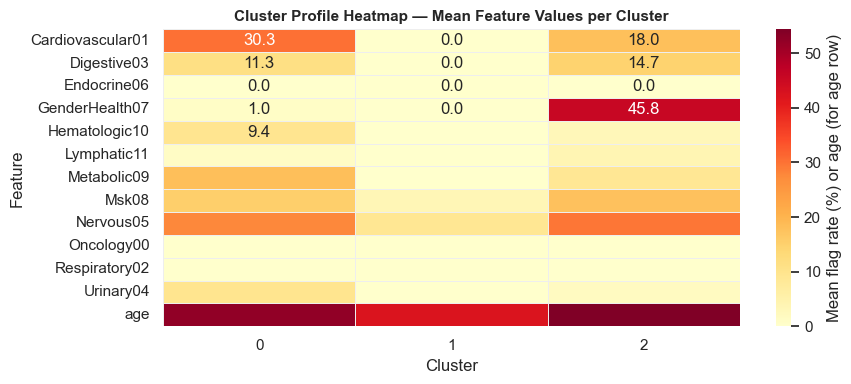


  PATIENT CLUSTER SUMMARY CARDS

  ┌─ Cluster 0  (24 patients) ────────────────────────────────────────
  │  Median age         : 52 yrs
  │  Dominant gender    : Male
  │  Top flagged organs :
  │    • Cardiovascular01             mean flag rate = 30.3%
  │    • Nervous05                    mean flag rate = 27.7%
  │    • Metabolic09                  mean flag rate = 18.2%
  └─────────────────────────────────────────────────────────

  ┌─ Cluster 1  (22 patients) ────────────────────────────────────────
  │  Median age         : 41 yrs
  │  Dominant gender    : Male
  │  Top flagged organs :
  │    • Nervous05                    mean flag rate = 8.9%
  │    • Msk08                        mean flag rate = 3.4%
  │    • Cardiovascular01             mean flag rate = 0.0%
  └─────────────────────────────────────────────────────────

  ┌─ Cluster 2  (16 patients) ────────────────────────────────────────
  │  Median age         : 58 yrs
  │  Dominant gender    : Female
  │  Top flagged org

In [11]:
# ── 5c. Fit KMeans with best k ────────────────────────────────────────────────
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X)
feat_matrix["cluster"] = cluster_labels

# ── 5d. PCA → 2D scatter ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_ * 100

CLUSTER_PALETTE = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868", 3: "#C44E52",
                   4: "#9467BD", 5: "#8C564B"}

fig, ax = plt.subplots(figsize=(9, 6))
for cid in sorted(feat_matrix["cluster"].unique()):
    mask = cluster_labels == cid
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=CLUSTER_PALETTE.get(cid, "#888"),
               s=70, alpha=0.8, edgecolors="white", linewidths=0.5,
               label=f"Cluster {cid}  (n={mask.sum()})", zorder=3)

ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance explained)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance explained)")
ax.set_title(f"Patient Clusters (KMeans k={BEST_K}) — PCA 2D Projection",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── 5e. Cluster profile heatmap ───────────────────────────────────────────────
organ_cols = [c for c in feat_matrix.columns if c.startswith("organ_")]
cluster_profile = feat_matrix.groupby("cluster")[organ_cols + ["age"]].mean()
cluster_profile.columns = [c.replace("organ_", "").replace("_flag_rate", "") for c in cluster_profile.columns]

fig, ax = plt.subplots(figsize=(max(8, len(cluster_profile.columns) * 0.7), 4))
sns.heatmap(cluster_profile.T, ax=ax, cmap="YlOrRd", annot=True, fmt=".1f",
            linewidths=0.4, linecolor="#eee",
            cbar_kws={"label": "Mean flag rate (%) or age (for age row)"})
ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")
ax.set_title(f"Cluster Profile Heatmap — Mean Feature Values per Cluster",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 5f. Plain-language cluster summary cards ──────────────────────────────────
print(f"\n{'='*68}")
print("  PATIENT CLUSTER SUMMARY CARDS")
print(f"{'='*68}")

pt_meta = unique_pts.set_index("patient_key")[["patient_age", "patient_gender"]].copy()
pt_meta["patient_gender"] = pt_meta["patient_gender"].str.lower().str.strip().fillna("unknown")

for cid in sorted(feat_matrix["cluster"].unique()):
    members = feat_matrix[feat_matrix["cluster"] == cid].index
    meta = pt_meta.loc[pt_meta.index.isin(members)]
    med_age = meta["patient_age"].median()
    dom_gender = meta["patient_gender"].mode()[0] if not meta.empty else "—"
    n_mem = len(members)

    # Top 3 flagged organs in this cluster
    organ_means = cluster_profile.loc[cid].drop("age", errors="ignore").sort_values(ascending=False)
    top3_organs = organ_means.head(3)

    print(f"\n  ┌─ Cluster {cid}  ({n_mem} patients) {'─'*40}")
    print(f"  │  Median age         : {med_age:.0f} yrs")
    print(f"  │  Dominant gender    : {dom_gender.capitalize()}")
    print(f"  │  Top flagged organs :")
    for organ, rate in top3_organs.items():
        print(f"  │    • {organ:<28} mean flag rate = {rate:.1f}%")
    print(f"  └{'─'*57}")

print(f"\n{'='*68}")

## 6. Unexpected / Clinically Noteworthy Findings

Four targeted analyses that surface surprising or paradoxical patterns:

1. **Youth paradox** — biomarkers where patients < 40 yrs have a *higher* flag rate than those ≥ 40  
2. **Gender gap** — organs where the flag rate difference between genders exceeds 20 percentage points  
3. **Outlier patients** — individuals with an unusually high total Bad/Critical count (> 2 SD above mean)  
4. **SoC biomarkers with high flag rates** — standard-of-care panel members (≥ 90% coverage) flagged in > 50% of measured patients

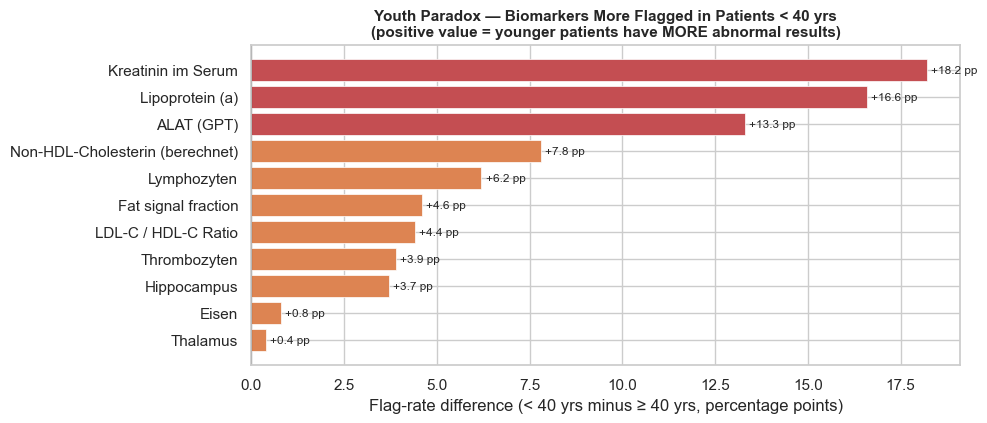

Found 11 biomarkers where patients < 40 yrs have a higher flag rate.


In [12]:
# ── 6a. Youth paradox: biomarkers with higher flag rate in <40 vs ≥40 ─────────
df_age_grp = df_dp.copy()
df_age_grp["patient_age_val"] = df_age_grp["patient_key"].map(age_map)
df_age_grp = df_age_grp.dropna(subset=["patient_age_val", "biomarker_name", "severity"])
df_age_grp["age_group"] = np.where(df_age_grp["patient_age_val"] < 40, "under_40", "40_plus")

# Flag rate per biomarker × age group
age_bio = (df_age_grp.groupby(["biomarker_name", "age_group"])
           .apply(lambda g: pd.Series({
               "n_pts": g["patient_key"].nunique(),
               "n_flagged": g[g["severity"].isin(["Bad","Critical"])]["patient_key"].nunique()
           }))
           .reset_index())
age_bio["flag_rate"] = (age_bio["n_flagged"] / age_bio["n_pts"] * 100).round(1)

age_pivot = (age_bio.pivot(index="biomarker_name", columns="age_group", values="flag_rate")
               .dropna())
if "under_40" in age_pivot.columns and "40_plus" in age_pivot.columns:
    age_pivot["youth_excess"] = age_pivot["under_40"] - age_pivot["40_plus"]
    youth_paradox = (age_pivot[age_pivot["youth_excess"] > 0]
                     .sort_values("youth_excess", ascending=True))

    if not youth_paradox.empty:
        fig, ax = plt.subplots(figsize=(10, max(4, len(youth_paradox) * 0.4)))
        colors_yp = ["#C44E52" if v >= 10 else "#DD8452" for v in youth_paradox["youth_excess"]]
        bars = ax.barh(youth_paradox.index, youth_paradox["youth_excess"],
                       color=colors_yp, edgecolor="white", linewidth=0.5)
        ax.bar_label(bars, fmt="+%.1f pp", padding=3, fontsize=8.5)
        ax.axvline(0, color="#333", linewidth=0.8)
        ax.set_xlabel("Flag-rate difference (< 40 yrs minus ≥ 40 yrs, percentage points)")
        ax.set_title("Youth Paradox — Biomarkers More Flagged in Patients < 40 yrs\n"
                     "(positive value = younger patients have MORE abnormal results)",
                     fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.show()
        print(f"Found {len(youth_paradox)} biomarkers where patients < 40 yrs have a higher flag rate.")
    else:
        print("No biomarkers show a higher flag rate in younger (<40) patients.")

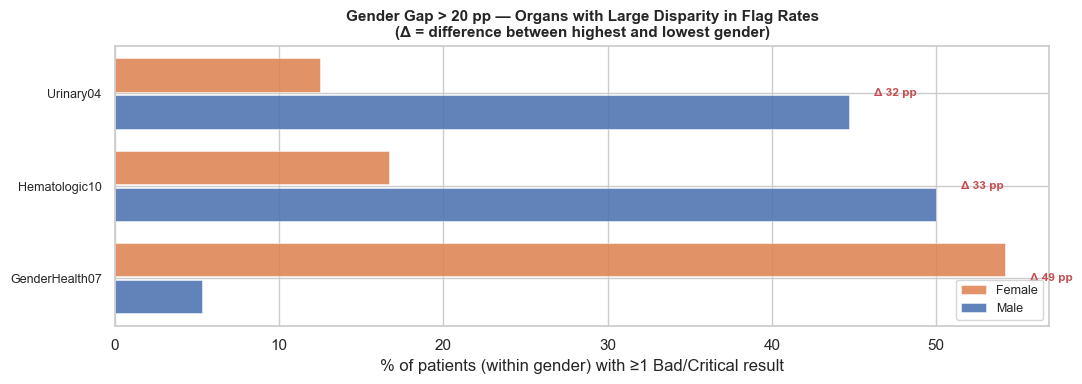

Found 3 organs with >20 pp gender gap in flag rates.


In [13]:
# ── 6b. Gender gap: organs where flag rate differs by > 20 pp between genders ──
GENDER_GAP_THRESHOLD = 20  # percentage points

flag_dp = df_dp[df_dp["severity"].isin(["Bad","Critical"])].copy()

# Patients per gender (denominator)
pts_gender_denom = (df_dp.drop_duplicates("patient_key")
                    .groupby("patient_gender")["patient_key"].nunique())

# Flag rate per organ × gender
organ_gender_flag = (flag_dp.dropna(subset=["organ"])
                     .groupby(["organ", "patient_gender"])["patient_key"]
                     .nunique()
                     .reset_index(name="n_flagged"))
organ_gender_flag["flag_rate"] = organ_gender_flag.apply(
    lambda r: r["n_flagged"] / pts_gender_denom.get(r["patient_gender"], N) * 100, axis=1
).round(1)

og_pivot = (organ_gender_flag.pivot(index="organ", columns="patient_gender", values="flag_rate")
              .fillna(0))

# Compute max gender gap across all gender pairs
gender_cols = [c for c in og_pivot.columns if c in ["male", "female", "other", "unknown"]]
if len(gender_cols) >= 2:
    og_pivot["max_gap"] = og_pivot[gender_cols].apply(
        lambda row: row.max() - row.min(), axis=1)
    large_gap = (og_pivot[og_pivot["max_gap"] >= GENDER_GAP_THRESHOLD]
                 .sort_values("max_gap", ascending=True))

    if not large_gap.empty:
        fig, ax = plt.subplots(figsize=(11, max(4, len(large_gap) * 0.5)))
        y = np.arange(len(large_gap))
        bar_h = 0.8 / max(len(gender_cols), 1)

        for i, gender in enumerate(gender_cols):
            if gender not in large_gap.columns:
                continue
            offset = (i - (len(gender_cols) - 1) / 2) * bar_h
            bars = ax.barh(y + offset, large_gap[gender].values,
                           height=bar_h * 0.9,
                           color=GENDER_COLORS.get(gender, "#888"),
                           label=gender.capitalize(),
                           edgecolor="white", linewidth=0.4, alpha=0.88)

        # Annotate max gap
        for yi, (organ_name, row) in enumerate(large_gap.iterrows()):
            ax.text(row[gender_cols].max() + 1.5, yi,
                    f"Δ {row['max_gap']:.0f} pp", va="center", fontsize=8.5,
                    color="#C44E52", fontweight="bold")

        ax.set_yticks(y)
        ax.set_yticklabels(large_gap.index, fontsize=9)
        ax.set_xlabel("% of patients (within gender) with ≥1 Bad/Critical result")
        ax.set_title(f"Gender Gap > {GENDER_GAP_THRESHOLD} pp — Organs with Large Disparity in Flag Rates\n"
                     "(Δ = difference between highest and lowest gender)",
                     fontsize=11, fontweight="bold")
        ax.invert_yaxis()
        ax.legend(fontsize=9, loc="lower right")
        plt.tight_layout()
        plt.show()
        print(f"Found {len(large_gap)} organs with >{GENDER_GAP_THRESHOLD} pp gender gap in flag rates.")
    else:
        print(f"No organs show a >{GENDER_GAP_THRESHOLD} pp gender gap in flag rates.")

Mean Bad/Critical datapoints per patient : 19.8
Std dev                                  : 4.8
2 SD threshold                           : 29.3
Outlier patients (>29 flagged dp) : 0


C:\Users\ABCLe\AppData\Local\Temp\ipykernel_7096\3750772061.py:43: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\ABCLe\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


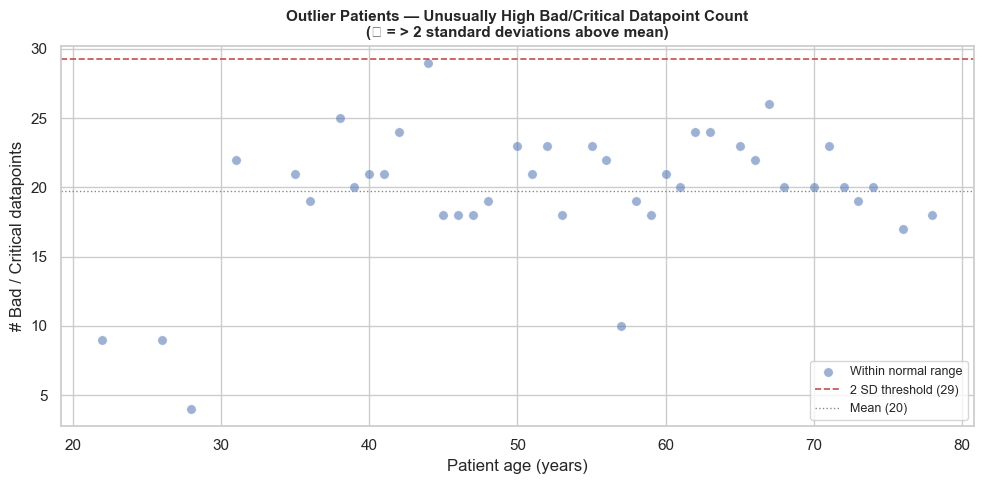

In [14]:
# ── 6c. Outlier patients: > 2 SD above mean Bad/Critical count ───────────────
flag_counts = (flagged.groupby("patient_key").size()
               .rename("n_flagged_dp").reset_index())
flag_counts["patient_age"] = flag_counts["patient_key"].map(age_map)
flag_counts["patient_gender"] = flag_counts["patient_key"].map(
    df_dp.drop_duplicates("patient_key").set_index("patient_key")["patient_gender"])

mean_f = flag_counts["n_flagged_dp"].mean()
std_f  = flag_counts["n_flagged_dp"].std()
outlier_thresh = mean_f + 2 * std_f

outlier_pts = flag_counts[flag_counts["n_flagged_dp"] > outlier_thresh].copy()
normal_pts  = flag_counts[flag_counts["n_flagged_dp"] <= outlier_thresh].copy()

print(f"Mean Bad/Critical datapoints per patient : {mean_f:.1f}")
print(f"Std dev                                  : {std_f:.1f}")
print(f"2 SD threshold                           : {outlier_thresh:.1f}")
print(f"Outlier patients (>{outlier_thresh:.0f} flagged dp) : {len(outlier_pts)}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(normal_pts["patient_age"].dropna(), normal_pts["n_flagged_dp"],
           color="#4C72B0", alpha=0.55, s=45, edgecolors="white", linewidths=0.4,
           label="Within normal range", zorder=2)
if not outlier_pts.empty:
    ax.scatter(outlier_pts["patient_age"].dropna(),
               outlier_pts[outlier_pts["patient_age"].notna()]["n_flagged_dp"],
               color="#C44E52", s=90, edgecolors="white", linewidths=0.8,
               marker="*", zorder=5, label="Outlier patient (>2 SD)")
    for _, row in outlier_pts.dropna(subset=["patient_age"]).iterrows():
        ax.annotate(f"  age {row['patient_age']:.0f}\n  ({row['n_flagged_dp']:.0f} dp)",
                    xy=(row["patient_age"], row["n_flagged_dp"]),
                    fontsize=7.5, color="#C44E52",
                    xytext=(5, 5), textcoords="offset points")

ax.axhline(outlier_thresh, color="#C44E52", linestyle="--", linewidth=1.2,
           label=f"2 SD threshold ({outlier_thresh:.0f})")
ax.axhline(mean_f, color="#888", linestyle=":", linewidth=1, label=f"Mean ({mean_f:.0f})")
ax.set_xlabel("Patient age (years)")
ax.set_ylabel("# Bad / Critical datapoints")
ax.set_title("Outlier Patients — Unusually High Bad/Critical Datapoint Count\n"
             "(* = > 2 standard deviations above mean)", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

if not outlier_pts.empty:
    print("\nOutlier patient details:")
    display(outlier_pts.sort_values("n_flagged_dp", ascending=False).reset_index(drop=True))

Standard-of-care biomarkers (≥90% coverage) flagged in >50% of patients: 2



C:\Users\ABCLe\AppData\Local\Temp\ipykernel_7096\3554963180.py:39: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .style.applymap(highlight_high, subset=["% flagged of measured"])


,biomarker_name,organ,source,% SoC coverage,% flagged of measured,n measured,n flagged
0,HbA1c nach NGSP,Metabolic09,Blood,95.2%,61.0%,59,36.000000
1,Cholesterin,Cardiovascular01,Blood,93.5%,51.7%,58,30.000000


C:\Users\ABCLe\AppData\Local\Temp\ipykernel_7096\3554963180.py:59: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.tight_layout()
c:\Users\ABCLe\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


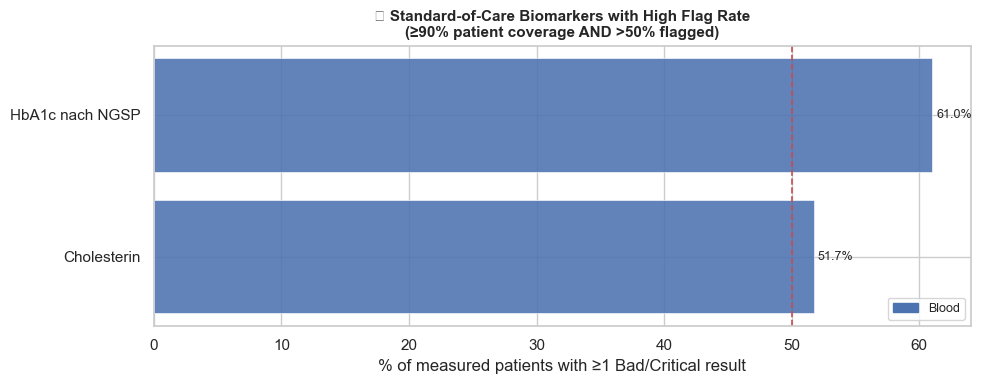

In [ ]:
# ── 6d. SoC biomarkers with high flag rates (≥90% coverage, >50% flagged) ─────
SOC_THRESHOLD  = 90   # % coverage to qualify as standard-of-care
FLAG_THRESHOLD = 50   # % of measured patients that must be flagged

# Patient coverage per biomarker (use biomarker_id as primary key)
bio_coverage = (df_dp.dropna(subset=["biomarker_id", "patient_key"])
                .groupby("biomarker_id")["patient_key"].nunique()
                .rename("n_measured"))
bio_flagged  = (flagged.dropna(subset=["biomarker_id", "patient_key"])
                .groupby("biomarker_id")["patient_key"].nunique()
                .rename("n_flagged"))

soc_flag = (pd.concat([bio_coverage, bio_flagged], axis=1)
              .fillna(0)
              .assign(pct_coverage=lambda d: d["n_measured"] / N * 100,
                      pct_flagged =lambda d: d["n_flagged"]  / d["n_measured"] * 100)
              .join(name_map.rename("biomarker_name"))
              .join(organ_map.rename("organ"))
              .join(source_map.rename("source"))
              .reset_index()
              .query("pct_coverage >= @SOC_THRESHOLD and pct_flagged > @FLAG_THRESHOLD")
              .sort_values("pct_flagged", ascending=False)
              .reset_index(drop=True))

print(f"Standard-of-care biomarkers (≥{SOC_THRESHOLD}% coverage) flagged in >{FLAG_THRESHOLD}% of patients: "
      f"{len(soc_flag)}\n")

if not soc_flag.empty:
    # Highlighted table
    def highlight_high(val):
        return "background-color: #C44E52; color: white; font-weight: bold" if isinstance(val, (int, float)) and val > FLAG_THRESHOLD else ""

    display(soc_flag[["biomarker_name", "organ", "source", "pct_coverage", "pct_flagged",
                        "n_measured", "n_flagged"]]
            .rename(columns={"pct_coverage": "% SoC coverage",
                              "pct_flagged":  "% flagged of measured",
                              "n_measured":   "n measured",
                              "n_flagged":    "n flagged"})
            .style.map(highlight_high, subset=["% flagged of measured"])
            .format({"% SoC coverage": "{:.1f}%", "% flagged of measured": "{:.1f}%"}))

    # Bar chart
    fig, ax = plt.subplots(figsize=(10, max(4, len(soc_flag) * 0.5)))
    bar_c = [SOURCE_COLORS.get(s, "#888") for s in soc_flag["source"]]
    bars = ax.barh(soc_flag["biomarker_name"], soc_flag["pct_flagged"],
                   color=bar_c, edgecolor="white", linewidth=0.5, alpha=0.88)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.axvline(FLAG_THRESHOLD, color="#C44E52", linestyle="--", linewidth=1.2,
               label=f"{FLAG_THRESHOLD}% flag threshold")

    legend_patches = [mpatches.Patch(color=c, label=s)
                      for s, c in SOURCE_COLORS.items() if s in soc_flag["source"].values]
    ax.legend(handles=legend_patches, fontsize=9, loc="lower right")
    ax.set_xlabel("% of measured patients with ≥1 Bad/Critical result")
    ax.set_title(f"[!] Standard-of-Care Biomarkers with High Flag Rate\n"
                 f"(≥{SOC_THRESHOLD}% patient coverage AND >{FLAG_THRESHOLD}% flagged)",
                 fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("✓ No standard-of-care biomarkers exceed the 50% flag threshold.")

## 7. Summary of Key Findings

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Most abnormal biomarkers** | See section 2 — top biomarkers ranked by % of cohort with Bad/Critical result |
| 2 | **Imaging prevalence** | See section 3 — share of patients with any / flagged imaging result per organ |
| 3 | **Deficiency biomarkers** | See section 3 — keyword-matched nutritional biomarkers and their flag rates |
| 4 | **Age–outcome correlation** | See section 4 — Spearman ρ table; heatmap reveals which organs worsen with age |
| 5 | **Gender disparities** | See section 4 & 6b — organs where flag rate gap between genders exceeds 20 pp |
| 6 | **Patient clusters** | See section 5 — KMeans segments with distinct age, gender, and organ profiles |
| 7 | **Youth paradox** | See section 6a — biomarkers where younger (<40) patients are *more* flagged |
| 8 | **Outlier patients** | See section 6c — patients with flag counts > 2 SD above the cohort mean |
| 9 | **High-risk SoC biomarkers** | See section 6d — standard-of-care tests flagged in > 50% of measured patients |

> **Reminder:** All data is synthetic. These findings describe the structure of the dataset, not real clinical prevalences.